## 1. Setup

In [ ]:
!pip install -q kagglehub librosa soundfile
import os, json, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, Input
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score, accuracy_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Getting the RAVDESS dataset

In [ ]:
import kagglehub
from google.colab import drive
drive.mount('/content/drive')
dataset_path = "/content/drive/MyDrive/Speech_Emotion_Recognition/data/ravdess/audio"


Mounted at /content/drive


In [ ]:
actor_dirs = []
for root, dirs, files in os.walk(dataset_path):
    for d in dirs:
        if d.lower().startswith("actor"):
            actor_dirs.append(os.path.join(root, d))
actor_dirs = sorted(set(actor_dirs))
print(f"Found {len(actor_dirs)} actor folders")
print(actor_dirs[:3])

Found 24 actor folders
['/content/drive/MyDrive/Speech_Emotion_Recognition/data/ravdess/audio/Actor_01', '/content/drive/MyDrive/Speech_Emotion_Recognition/data/ravdess/audio/Actor_02', '/content/drive/MyDrive/Speech_Emotion_Recognition/data/ravdess/audio/Actor_03']


## 3. Building the file index

In [ ]:
EMOTION_MAP = {
    "01": "neutral", "02": "calm", "03": "happy", "04": "sad",
    "05": "angry", "06": "fearful", "07": "disgust", "08": "surprised",
}
EMOTIONS = list(EMOTION_MAP.values())
EMOTION_TO_IDX = {e: i for i, e in enumerate(EMOTIONS)}

records = []
for actor_dir in actor_dirs:
    for fname in os.listdir(actor_dir):
        if not fname.lower().endswith(".wav"):
            continue
        parts = fname.replace(".wav", "").split("-")
        if len(parts) != 7:
            continue
        modality, vocal_channel, emotion, intensity, statement, repetition, actor = parts
        records.append({
            "filepath": os.path.join(actor_dir, fname),
            "emotion": EMOTION_MAP[emotion],
            "actor": int(actor),
            "gender": "male" if int(actor) % 2 == 1 else "female",
        })

df = pd.DataFrame(records)
assert len(df) == 1440, f"Expected 1440 files, found {len(df)} — check dataset_path above"
print(f"Total files indexed: {len(df)}")
df.head()

Total files indexed: 1440


,filepath,emotion,actor,gender
0,/content/drive/MyDrive/Speech_Emotion_Recognit...,disgust,1,male
1,/content/drive/MyDrive/Speech_Emotion_Recognit...,disgust,1,male
2,/content/drive/MyDrive/Speech_Emotion_Recognit...,angry,1,male
3,/content/drive/MyDrive/Speech_Emotion_Recognit...,calm,1,male
4,/content/drive/MyDrive/Speech_Emotion_Recognit...,angry,1,male


## 4. Speaker-independent split

In [ ]:
TEST_ACTORS = [21, 22, 23, 24]
VAL_ACTORS  = [17, 18, 19, 20]
TRAIN_ACTORS = [a for a in range(1, 25) if a not in TEST_ACTORS + VAL_ACTORS]

train_df = df[df.actor.isin(TRAIN_ACTORS)].reset_index(drop=True)
val_df   = df[df.actor.isin(VAL_ACTORS)].reset_index(drop=True)
test_df  = df[df.actor.isin(TEST_ACTORS)].reset_index(drop=True)

print(f"Train: {len(train_df)} files, {train_df.actor.nunique()} actors")
print(f"Val:   {len(val_df)} files, {val_df.actor.nunique()} actors")
print(f"Test:  {len(test_df)} files, {test_df.actor.nunique()} actors")

Train: 960 files, 16 actors
Val:   240 files, 4 actors
Test:  240 files, 4 actors


## 5. Preprocessing, augmentation, and feature extraction

In [ ]:
SR = 16000
DURATION = 4.0
N_SAMPLES = int(SR * DURATION)

N_MELS = 64
N_FFT = 1024
HOP_LENGTH = 256
N_MFCC = 40


def normalize_audio(audio):
    peak = np.max(np.abs(audio))
    return audio / peak if peak > 0 else audio


def load_raw(filepath, sr=SR):
    audio, _ = librosa.load(filepath, sr=sr, mono=True)
    return normalize_audio(audio)


def fix_length(audio, n_samples=N_SAMPLES):
    if len(audio) < n_samples:
        audio = np.pad(audio, (0, n_samples - len(audio)))
    else:
        audio = audio[:n_samples]
    return audio


def augment_pitch(audio, sr=SR):
    n_steps = np.random.uniform(-2, 2)
    return normalize_audio(librosa.effects.pitch_shift(y=audio, sr=sr, n_steps=n_steps))


def augment_time_stretch(audio):
    rate = np.random.uniform(0.9, 1.1)
    return normalize_audio(librosa.effects.time_stretch(y=audio, rate=rate))


def augment_noise(audio, noise_factor=0.005):
    noise = np.random.randn(len(audio))
    return normalize_audio(audio + noise_factor * noise)


def get_training_variants(audio):
    # original + 3 augmented versions
    return [audio, augment_pitch(audio), augment_time_stretch(audio), augment_noise(audio)]


def extract_features(audio, sr=SR):
    mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS)
    log_mel = librosa.power_to_db(mel, ref=np.max)
    log_mel = (log_mel - log_mel.mean()) / (log_mel.std() + 1e-8)

    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP_LENGTH)
    mfcc = (mfcc - mfcc.mean()) / (mfcc.std() + 1e-8)

    return log_mel.astype(np.float32), mfcc.astype(np.float32)


def spec_augment(log_mel, freq_mask_param=8, time_mask_param=20, num_masks=1):
    log_mel = log_mel.copy()
    n_mels, T = log_mel.shape
    fill_value = log_mel.mean()
    for _ in range(num_masks):
        f = np.random.randint(0, freq_mask_param + 1)
        f0 = np.random.randint(0, max(n_mels - f, 1))
        log_mel[f0:f0 + f, :] = fill_value

        t = np.random.randint(0, time_mask_param + 1)
        t0 = np.random.randint(0, max(T - t, 1))
        log_mel[:, t0:t0 + t] = fill_value
    return log_mel


# Quick sanity check
_sample_audio = load_raw(df.filepath.iloc[0])
_variants = get_training_variants(_sample_audio)
print(f"Generated {len(_variants)} variants (original + 3 augmented) from one file")
_mel, _mfcc = extract_features(fix_length(_variants[0]))
print("Log-Mel shape:", _mel.shape, " | MFCC shape:", _mfcc.shape)

Generated 4 variants (original + 3 augmented) from one file
Log-Mel shape: (64, 251)  | MFCC shape: (40, 251)


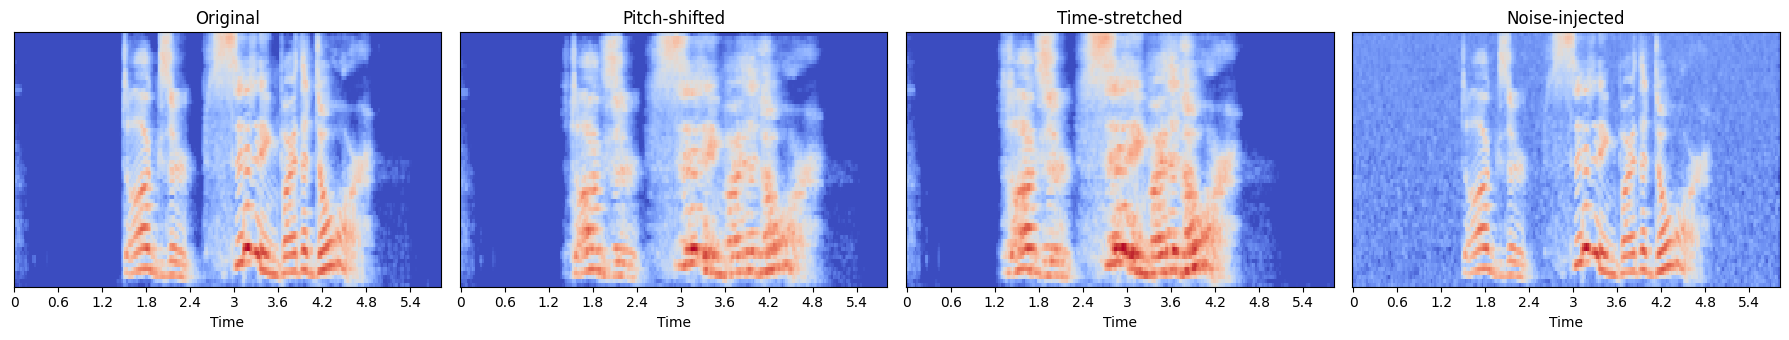

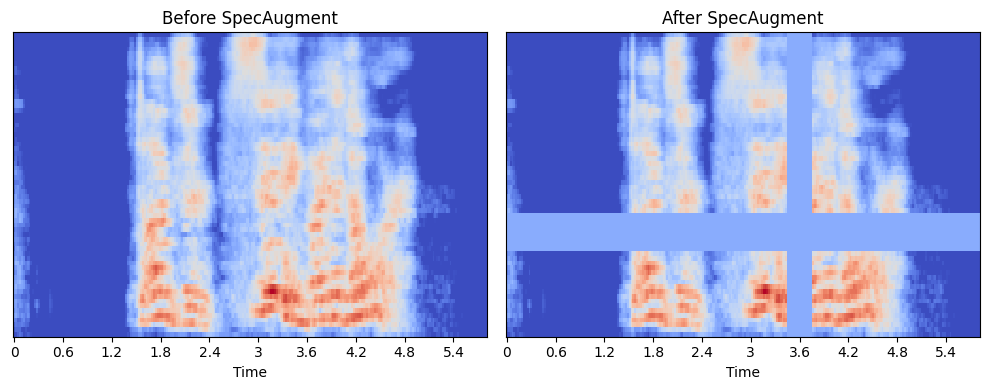

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 3.5))
titles = ["Original", "Pitch-shifted", "Time-stretched", "Noise-injected"]
for ax, variant, title in zip(axes, _variants, titles):
    mel, _ = extract_features(fix_length(variant))
    librosa.display.specshow(mel, x_axis='time', ax=ax)
    ax.set_title(title)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
mel_aug, _ = extract_features(fix_length(_variants[1]))
librosa.display.specshow(mel_aug, x_axis='time', ax=axes[0])
axes[0].set_title("Before SpecAugment")
librosa.display.specshow(spec_augment(mel_aug), x_axis='time', ax=axes[1])
axes[1].set_title("After SpecAugment")
plt.tight_layout()
plt.show()

## 6. Building the feature dataset (augmented for train, plain for val/test)

In [ ]:
CACHE_PATH = "/content/ravdess_features_v2.npz"   # new cache file — v1's cache is not reused


def build_feature_arrays(frame, augment=False):
    mels, mfccs, labels, actors = [], [], [], []
    for _, row in frame.iterrows():
        raw = load_raw(row.filepath)
        variants = get_training_variants(raw) if augment else [raw]
        for vi, v in enumerate(variants):
            v_fixed = fix_length(v)
            mel, mfcc = extract_features(v_fixed)
            if augment and vi > 0:          # spec-augment only the augmented copies, not the original
                mel = spec_augment(mel)
            mels.append(mel)
            mfccs.append(mfcc)
            labels.append(EMOTION_TO_IDX[row.emotion])
            actors.append(row.actor)
    return (np.stack(mels)[..., np.newaxis],
            np.transpose(np.stack(mfccs), (0, 2, 1)),
            np.array(labels), np.array(actors))


if os.path.exists(CACHE_PATH):
    print("Loading cached features...")
    d = np.load(CACHE_PATH)
    X_mel_train, X_mfcc_train, y_train = d["mel_tr"], d["mfcc_tr"], d["y_tr"]
    X_mel_val,   X_mfcc_val,   y_val   = d["mel_va"], d["mfcc_va"], d["y_va"]
    X_mel_test,  X_mfcc_test,  y_test  = d["mel_te"], d["mfcc_te"], d["y_te"]
else:
    print("Extracting + augmenting features for train set (this is the slow one)...")
    X_mel_train, X_mfcc_train, y_train, _ = build_feature_arrays(train_df, augment=True)
    print("Extracting features for val set...")
    X_mel_val,   X_mfcc_val,   y_val,   _ = build_feature_arrays(val_df, augment=False)
    print("Extracting features for test set...")
    X_mel_test,  X_mfcc_test,  y_test,  _ = build_feature_arrays(test_df, augment=False)

    np.savez_compressed(
        CACHE_PATH,
        mel_tr=X_mel_train, mfcc_tr=X_mfcc_train, y_tr=y_train,
        mel_va=X_mel_val,   mfcc_va=X_mfcc_val,   y_va=y_val,
        mel_te=X_mel_test,  mfcc_te=X_mfcc_test,  y_te=y_test,
    )
    print("Cached to", CACHE_PATH)

print("Train:", X_mel_train.shape, X_mfcc_train.shape, y_train.shape, " (should be ~4x the original 960)")
print("Val:  ", X_mel_val.shape, X_mfcc_val.shape, y_val.shape)
print("Test: ", X_mel_test.shape, X_mfcc_test.shape, y_test.shape)

Extracting + augmenting features for train set (this is the slow one)...
Extracting features for val set...
Extracting features for test set...
Cached to /content/ravdess_features_v2.npz
Train: (3840, 64, 251, 1) (3840, 251, 40) (3840,)  (should be ~4x the original 960)
Val:   (240, 64, 251, 1) (240, 251, 40) (240,)
Test:  (240, 64, 251, 1) (240, 251, 40) (240,)


In [ ]:
class_weight_values = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: w for i, w in enumerate(class_weight_values)}
class_weight_dict

{0: np.float64(1.875),
 1: np.float64(0.9375),
 2: np.float64(0.9375),
 3: np.float64(0.9375),
 4: np.float64(0.9375),
 5: np.float64(0.9375),
 6: np.float64(0.9375),
 7: np.float64(0.9375)}

## 7. Models

In [ ]:
MEL_SHAPE = X_mel_train.shape[1:]
MFCC_SHAPE = X_mfcc_train.shape[1:]
NUM_CLASSES = len(EMOTIONS)
L2_REG = 1e-4


def build_cnn_branch(mel_input):
    x = layers.Conv2D(16, 3, padding="same", kernel_regularizer=l2(L2_REG))(mel_input)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Conv2D(32, 3, padding="same", kernel_regularizer=l2(L2_REG))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Conv2D(64, 3, padding="same", kernel_regularizer=l2(L2_REG))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.4)(x)

    x = layers.GlobalAveragePooling2D()(x)
    return x


def build_bilstm_branch(mfcc_input):
    x = layers.Bidirectional(layers.LSTM(32, return_sequences=True, kernel_regularizer=l2(L2_REG)))(mfcc_input)
    x = layers.Dropout(0.4)(x)
    x = layers.Bidirectional(layers.LSTM(16, kernel_regularizer=l2(L2_REG)))(x)
    x = layers.Dropout(0.4)(x)
    return x


def build_cnn_baseline():
    mel_input = Input(shape=MEL_SHAPE, name="mel_input")
    cnn_features = build_cnn_branch(mel_input)
    x = layers.Dense(64, activation="relu", kernel_regularizer=l2(L2_REG))(cnn_features)
    x = layers.Dropout(0.5)(x)
    output = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    return models.Model(inputs=mel_input, outputs=output, name="CNN_Baseline_v2")


def build_hybrid_model():
    mel_input = Input(shape=MEL_SHAPE, name="mel_input")
    mfcc_input = Input(shape=MFCC_SHAPE, name="mfcc_input")
    cnn_features = build_cnn_branch(mel_input)
    bilstm_features = build_bilstm_branch(mfcc_input)
    fused = layers.Concatenate(name="feature_fusion")([cnn_features, bilstm_features])
    x = layers.Dense(64, activation="relu", kernel_regularizer=l2(L2_REG))(fused)
    x = layers.Dropout(0.5)(x)
    output = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    return models.Model(inputs=[mel_input, mfcc_input], outputs=output, name="Hybrid_CNN_BiLSTM_v2")


cnn_baseline = build_cnn_baseline()
cnn_baseline.summary()

Model: "CNN_Baseline_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mel_input (InputLayer)          │ (None, 64, 251, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 251, 16)    │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 251, 16)    │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 64, 251, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 125, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 125, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 125, 32)    │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 125, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32, 125, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 62, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 62, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 16, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 31, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 31, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,424 (111.03 KB)

 Trainable params: 28,200 (110.16 KB)

 Non-trainable params: 224 (896.00 B)

In [ ]:
hybrid_model = build_hybrid_model()
hybrid_model.summary()

Model: "Hybrid_CNN_BiLSTM_v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mel_input           │ (None, 64, 251,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 251,   │        160 │ mel_input[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 251,   │         64 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 64, 251,   │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 32, 125,   │          0 │ re_lu_3[0][0]     │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 32, 125,   │          0 │ max_pooling2d_3[… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 125,   │      4,640 │ dropout_4[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 125,   │        128 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 32, 125,   │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 16, 62,    │          0 │ re_lu_4[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 16, 62,    │          0 │ max_pooling2d_4[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 16, 62,    │     18,496 │ dropout_5[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 62,    │        256 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mfcc_input          │ (None, 251, 40)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_5 (ReLU)      │ (None, 16, 62,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 251, 64)   │     18,688 │ mfcc_input[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 8, 31, 64) │          0 │ re_lu_5[0][0]   

 Total params: 59,528 (232.53 KB)

 Trainable params: 59,304 (231.66 KB)

 Non-trainable params: 224 (896.00 B)

## 8. Training setup

In [ ]:
def compile_model(model):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def get_callbacks(name):
    return [
        callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6),
        callbacks.ModelCheckpoint(f"{name}_best.keras", monitor="val_accuracy", save_best_only=True),
    ]

BATCH_SIZE = 32
EPOCHS = 40   # a bit higher since patience is higher and there's more (augmented) data per epoch

### 8.1 Training CNN baseline

In [ ]:
cnn_baseline = compile_model(cnn_baseline)

history_cnn = cnn_baseline.fit(
    X_mel_train, y_train,
    validation_data=(X_mel_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=get_callbacks("cnn_baseline_v2"),
    verbose=1,
)

Epoch 1/40
120/120 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.1680 - loss: 2.0914 - val_accuracy: 0.1333 - val_loss: 2.2299 - learning_rate: 0.0010
Epoch 2/40
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.1961 - loss: 2.0230 - val_accuracy: 0.0667 - val_loss: 2.4007 - learning_rate: 0.0010
Epoch 3/40
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.2237 - loss: 1.9694 - val_accuracy: 0.1458 - val_loss: 2.3259 - learning_rate: 0.0010
Epoch 4/40
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.2479 - loss: 1.9249 - val_accuracy: 0.1458 - val_loss: 2.3329 - learning_rate: 0.0010
Epoch 5/40
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.2643 - loss: 1.8923 - val_accuracy: 0.1833 - val_loss: 2.1402 - learning_rate: 0.0010
Epoch 6/40
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.2854 - loss: 1.8537 - val_accuracy: 0.2458 - val_loss: 2.0145 - learning_rate: 0.0010
Epoch 7/40
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.2901 - loss: 1

### 8.2 Training Hybrid CNN-BiLSTM

In [ ]:
hybrid_model = compile_model(hybrid_model)

history_hybrid = hybrid_model.fit(
    [X_mel_train, X_mfcc_train], y_train,
    validation_data=([X_mel_val, X_mfcc_val], y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=get_callbacks("hybrid_cnn_bilstm_v2"),
    verbose=1,
)

Epoch 1/40
120/120 ━━━━━━━━━━━━━━━━━━━━ 17s 56ms/step - accuracy: 0.1495 - loss: 2.1230 - val_accuracy: 0.1333 - val_loss: 2.2178 - learning_rate: 0.0010
Epoch 2/40
120/120 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - accuracy: 0.1583 - loss: 2.0706 - val_accuracy: 0.1333 - val_loss: 2.3835 - learning_rate: 0.0010
Epoch 3/40
120/120 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.1844 - loss: 2.0429 - val_accuracy: 0.1333 - val_loss: 2.4708 - learning_rate: 0.0010
Epoch 4/40
120/120 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - accuracy: 0.2091 - loss: 2.0084 - val_accuracy: 0.1333 - val_loss: 2.3706 - learning_rate: 0.0010
Epoch 5/40
120/120 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.2096 - loss: 1.9811 - val_accuracy: 0.1792 - val_loss: 2.3049 - learning_rate: 0.0010
Epoch 6/40
120/120 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - accuracy: 0.2497 - loss: 1.9379 - val_accuracy: 0.1833 - val_loss: 2.2085 - learning_rate: 5.0000e-04
Epoch 7/40
120/120 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.2583 - los

## 9. Training curves

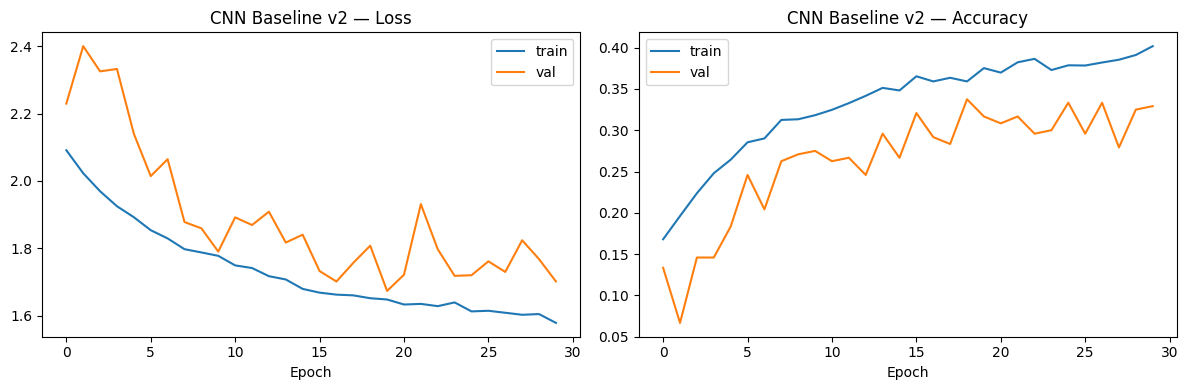

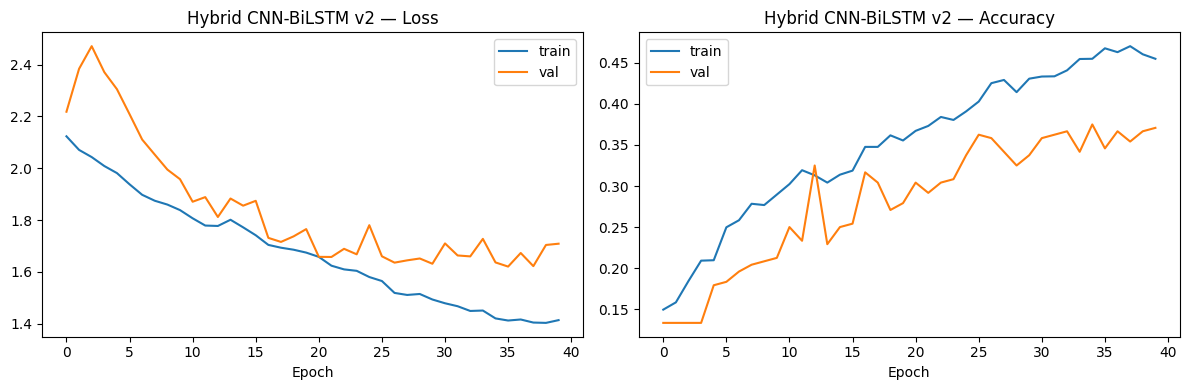

In [ ]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history["loss"], label="train")
    axes[0].plot(history.history["val_loss"], label="val")
    axes[0].set_title(f"{title} — Loss")
    axes[0].set_xlabel("Epoch"); axes[0].legend()

    axes[1].plot(history.history["accuracy"], label="train")
    axes[1].plot(history.history["val_accuracy"], label="val")
    axes[1].set_title(f"{title} — Accuracy")
    axes[1].set_xlabel("Epoch"); axes[1].legend()
    plt.tight_layout()
    plt.show()

plot_history(history_cnn, "CNN Baseline v2")
plot_history(history_hybrid, "Hybrid CNN-BiLSTM v2")

## 10. Evaluation on the held-out test set

=== CNN Baseline v2 ===
Accuracy:  0.4375
Precision: 0.3769
Recall:    0.4453
F1-score:  0.3582

              precision    recall  f1-score   support

     neutral       0.19      0.56      0.28        16
        calm       0.44      0.88      0.59        32
       happy       0.00      0.00      0.00        32
         sad       0.00      0.00      0.00        32
       angry       0.44      0.25      0.32        32
     fearful       0.90      0.28      0.43        32
     disgust       0.49      0.59      0.54        32
   surprised       0.55      1.00      0.71        32

    accuracy                           0.44       240
   macro avg       0.38      0.45      0.36       240
weighted avg       0.39      0.44      0.36       240



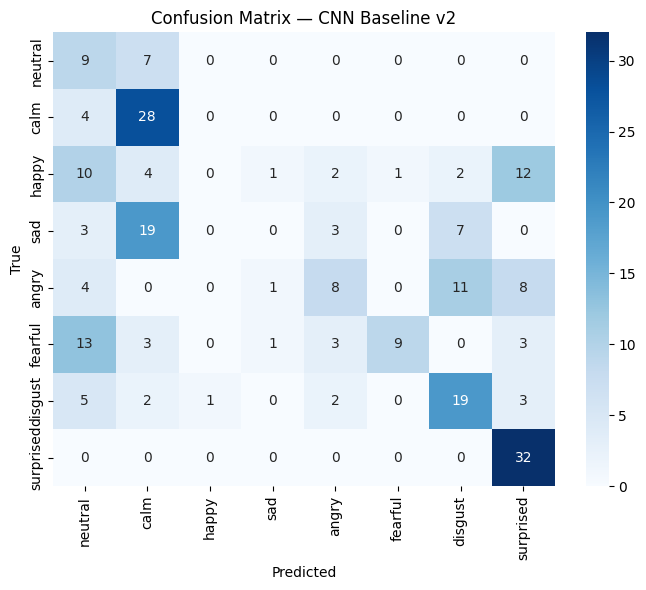

=== Hybrid CNN-BiLSTM v2 ===
Accuracy:  0.4167
Precision: 0.3611
Recall:    0.4297
F1-score:  0.3763

              precision    recall  f1-score   support

     neutral       0.24      0.62      0.35        16
        calm       0.53      0.72      0.61        32
       happy       0.00      0.00      0.00        32
         sad       0.33      0.22      0.26        32
       angry       0.56      0.62      0.59        32
     fearful       0.39      0.34      0.37        32
     disgust       0.43      0.28      0.34        32
   surprised       0.40      0.62      0.49        32

    accuracy                           0.42       240
   macro avg       0.36      0.43      0.38       240
weighted avg       0.37      0.42      0.38       240



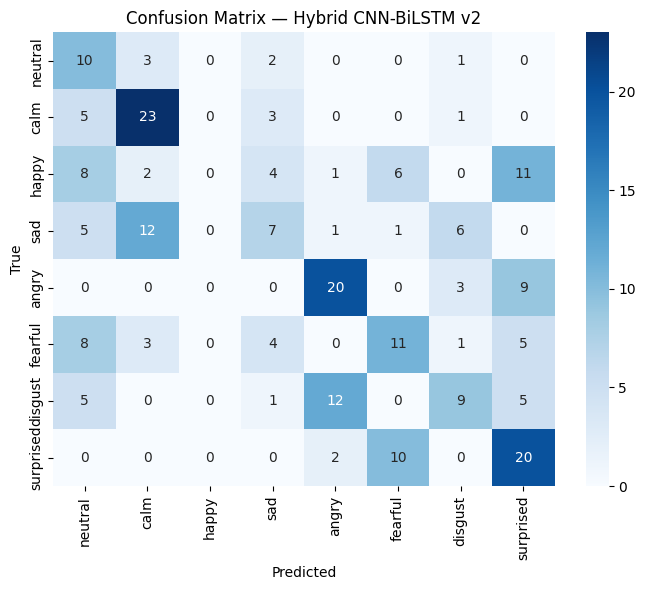

,accuracy,precision,recall,f1
model,,,,
CNN Baseline v2,0.437500,0.376912,0.445312,0.358202
Hybrid CNN-BiLSTM v2,0.416667,0.361138,0.429688,0.376336


In [ ]:
def evaluate_model(model, inputs, y_true, name):
    probs = model.predict(inputs, verbose=0)
    y_pred = np.argmax(probs, axis=1)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    print(f"=== {name} ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}\n")
    print(classification_report(y_true, y_pred, target_names=EMOTIONS, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=EMOTIONS, yticklabels=EMOTIONS)
    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    return {"model": name, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1}


results = []
results.append(evaluate_model(cnn_baseline, X_mel_test, y_test, "CNN Baseline v2"))
results.append(evaluate_model(hybrid_model, [X_mel_test, X_mfcc_test], y_test, "Hybrid CNN-BiLSTM v2"))

results_df = pd.DataFrame(results).set_index("model")
results_df

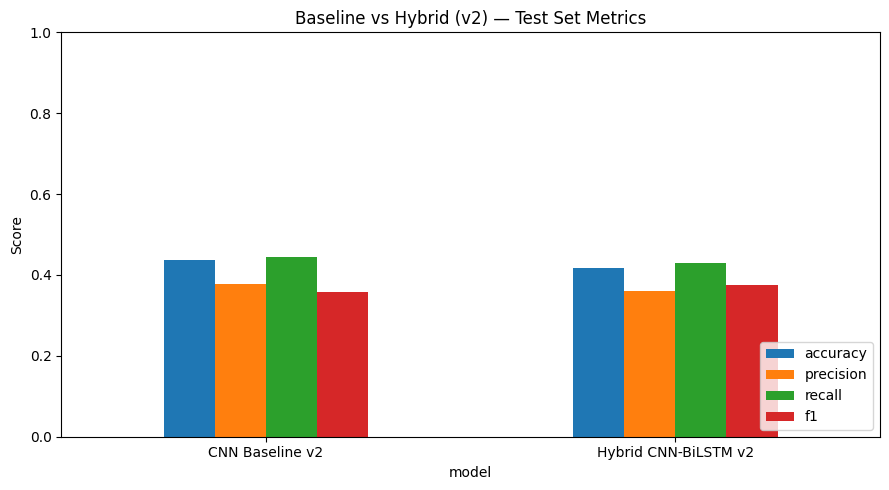

In [ ]:
results_df.plot(kind="bar", figsize=(9, 5), ylim=(0, 1))
plt.title("Baseline vs Hybrid (v2) — Test Set Metrics")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 11. Saving artifacts for the Streamlit UI

In [ ]:
import zipfile

hybrid_model.save("hybrid_cnn_bilstm_final_v2.keras")

with open("label_map.json", "w") as f:
    json.dump({i: e for i, e in enumerate(EMOTIONS)}, f, indent=2)

feature_config = {
    "sr": SR, "duration": DURATION, "n_mels": N_MELS,
    "n_fft": N_FFT, "hop_length": HOP_LENGTH, "n_mfcc": N_MFCC,
}
with open("feature_config.json", "w") as f:
    json.dump(feature_config, f, indent=2)

with zipfile.ZipFile("ser_model_bundle_v2.zip", "w") as zf:
    zf.write("hybrid_cnn_bilstm_final_v2.keras")
    zf.write("label_map.json")
    zf.write("feature_config.json")

print("Saved: hybrid_cnn_bilstm_final_v2.keras, label_map.json, feature_config.json")
print("Bundled into ser_model_bundle_v2.zip — download this from the Colab file browser")
print("(or: from google.colab import files; files.download('ser_model_bundle_v2.zip'))")

Saved: hybrid_cnn_bilstm_final_v2.keras, label_map.json, feature_config.json
Bundled into ser_model_bundle_v2.zip — download this from the Colab file browser
(or: from google.colab import files; files.download('ser_model_bundle_v2.zip'))


## 12. Quick inference sanity check

In [ ]:
sample_row = test_df.sample(1, random_state=SEED).iloc[0]
audio = fix_length(load_raw(sample_row.filepath))
mel, mfcc = extract_features(audio)
mel_in = mel[np.newaxis, ..., np.newaxis]
mfcc_in = mfcc.T[np.newaxis, ...]

probs = hybrid_model.predict([mel_in, mfcc_in], verbose=0)[0]
pred_idx = np.argmax(probs)

print(f"File: {os.path.basename(sample_row.filepath)}")
print(f"True emotion: {sample_row.emotion}")
print(f"Predicted:    {EMOTIONS[pred_idx]}  (confidence {probs[pred_idx]:.2%})")
print()
for e, p in sorted(zip(EMOTIONS, probs), key=lambda x: -x[1]):
    print(f"  {e:<10s} {p:.2%}")

File: 03-01-04-02-02-01-21.wav
True emotion: sad
Predicted:    disgust  (confidence 47.72%)

  disgust    47.72%
  angry      29.56%
  happy      7.58%
  sad        5.24%
  calm       4.02%
  surprised  3.27%
  neutral    1.56%
  fearful    1.06%
